In [ ]:
%pip install torch



^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch

In [2]:
import torch.nn as nn


In [5]:
%pip install tiktoken

   ---------------------------------------- 0.0/879.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/879.1 kB ? eta -:--:--
   ---------------------------------------- 879.1/879.1 kB 3.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}


In [5]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps=1e-5
    self.scale=nn.Parameter(torch.ones(emb_dim))
    self.shift=nn.Parameter(torch.zeros(emb_dim))
  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True,unbiased=True)
    norm_x=(x-mean)/torch.sqrt(var+self.eps)
    return self.scale*norm_x+self.shift

In [6]:
import math

In [7]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                math.sqrt(2.0 / math.pi) * (x + 0.044715 * x**3)
            )
        )

In [8]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
        GELU(),
        nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
    )
  def forward(self,x):
    return self.layers(x)

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )
    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec


In [10]:
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiHeadAttention(
      d_in=cfg["emb_dim"],
      d_out=cfg["emb_dim"],
      context_length=cfg["context_length"],
      num_heads=cfg["n_heads"],
      dropout=cfg["drop_rate"],
      qkv_bias=cfg["qkv_bias"])
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut=nn.Dropout(cfg["drop_rate"])
  def forward(self,x):
    shortcut=x
    x=self.norm1(x)
    x=self.att(x)
    x=self.drop_shortcut(x)
    x+=shortcut
    shortcut=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_shortcut(x)
    x+=shortcut
    return x

In [11]:
# Token Embedding
# Positional Embedding
# Input Embedding=Token Embedding + Positional Embedding
# Dropout (Randomly turn off embedding elements to zero with a probability of p)
# Transformer

  ## Layer Normalization(with mean =0 variance =1)
  ## Masked Multi head attention to Generate contect vector embedding using attention weight for no of head
  ## Dropout
  ## Shortcut connection(prevents VGD)
  ## Layer Norm
  ## Feed Forward (expnasion and contraction)
  ## Output dimension is same as input
  ## Dropout
  ## Shortcut Connection
  ## Transformer block Output
# Layer Normalisation
# Output Head(Neural layer (emb_dim*vocab size))
# Output Logits for each word we have vocabsize no of token
# Batch_size *cotext size * vocab size




In [12]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [13]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
batch=torch.tensor(
    [[6109,3626,6100,345],
     [6109,1110,6622,257]]
)
out=model(batch)
print(f"Batch is :{batch}")
print(f"\nOutput shape:{out.shape}")
print(out)

Batch is :tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape:torch.Size([2, 4, 50257])
tensor([[[-1.7930e-01,  2.8437e-01, -7.6031e-01,  ..., -4.8328e-01,
          -4.2459e-01, -1.7183e-01],
         [-6.2540e-01, -3.7472e-01, -9.6911e-01,  ...,  1.9217e-01,
          -1.3227e+00, -2.7610e-01],
         [ 5.1774e-01,  1.3858e-01,  2.4931e-01,  ...,  3.5055e-01,
          -7.7138e-02, -7.9681e-02],
         [-2.5624e-01, -6.9668e-01, -9.9378e-01,  ..., -4.4322e-02,
           6.1900e-02,  1.3455e-01]],

        [[-2.2345e-01,  1.1610e-01, -9.9719e-01,  ..., -1.5698e-01,
          -4.4743e-01, -2.8685e-02],
         [-8.7201e-01, -3.9409e-01, -1.1089e+00,  ...,  3.3024e-01,
          -9.2300e-02, -9.1344e-05],
         [ 4.5925e-01, -1.4261e-01, -1.2172e-01,  ...,  2.7475e-01,
           5.8875e-02, -9.0158e-02],
         [-6.2152e-01, -4.4847e-01, -4.7587e-01,  ..., -3.6475e-01,
           3.4392e-01, -3.8138e-01]]], grad_fn=<UnsafeViewBackward0>)


In [14]:
total_params=sum(p.numel() for p in model.parameters())
print(f"total number of parameters:{total_params:,}")

total number of parameters:162,419,712


In [15]:
def gen_text(model,idx,max_new_tokens,context_size):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]
    probabs=torch.softmax(logits,dim=-1)
    idx_next = torch.multinomial(probabs, num_samples=1)
    idx=torch.cat((idx,idx_next),dim=1)
  return idx


In [16]:
torch.manual_seed(123)
start_content="hello,I am"
encoded=tokenizer.encode(start_content)
print("Encoded",encoded)
encoded_tensor=torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor_shape",encoded_tensor.shape)

Encoded [31373, 11, 40, 716]
encoded_tensor_shape torch.Size([1, 4])


In [17]:
model.eval()
out=gen_text(model=model,idx=encoded_tensor,max_new_tokens=10,context_size=GPT_CONFIG_124M["context_length"])
print("Output",out)
print(len(out[0]))

Output tensor([[31373,    11,    40,   716, 44028, 14837, 13706, 30782, 20311, 47845,
         28936, 43558,  5724,  9426]])
14


In [18]:
decoded_text=tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

hello,I amenegger rendering GroundTempfinalTweetntonbanks rot gal


In [19]:
def text_token(text,tokenizer):
  encoded=tokenizer.encode(text,allowed_special={'<|endoftext|>'})
  encoded_tensor=torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor
def token_text(token_ids,tokenizer):
  flat=token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())
start_content="Every effort moves you"
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=gen_text(
    model=model,
    idx=text_token(start_content,tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text\n",token_text(token_ids,tokenizer))

Output text
 Every effort moves you reduUNEition sourced planesーティ KrishluenceoungeIsraeli


In [20]:
inputs=torch.tensor([[16833,3626,6100],
                     [40,1107,588]])
targets=torch.tensor([[3626,6100,345],
                      [1107,588,11311]])


In [21]:
with torch.no_grad():
  logits=model(inputs)
probabs=torch.softmax(logits,dim=-1)
print(probabs,"\n",probabs.shape)


tensor([[[1.8852e-05, 1.5172e-05, 1.1698e-05,  ..., 2.2408e-05,
          6.9822e-06, 1.8781e-05],
         [9.1619e-06, 1.0067e-05, 7.8848e-06,  ..., 2.9088e-05,
          6.0139e-06, 1.3577e-05],
         [2.9887e-05, 8.8599e-06, 1.5754e-05,  ..., 3.5435e-05,
          1.4104e-05, 1.3535e-05]],

        [[1.2571e-05, 2.0535e-05, 1.4342e-05,  ..., 1.0396e-05,
          3.4776e-05, 1.4245e-05],
         [7.2785e-06, 1.7863e-05, 1.0568e-05,  ..., 2.1211e-05,
          1.1390e-05, 1.5565e-05],
         [2.9499e-05, 3.3594e-05, 4.1009e-05,  ..., 6.5304e-06,
          5.8152e-05, 1.3705e-05]]]) 
 torch.Size([2, 3, 50257])


In [22]:
token_ids=torch.argmax(probabs,dim=-1,keepdim=True)
print("Token IDs:\n",token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [23]:
print(f"Targets batch 1:{token_text(targets[0],tokenizer)}")
print(f"Targets batch 1:{token_text(token_ids[0].flatten(),tokenizer)}")

Targets batch 1: effort moves you
Targets batch 1: Armed heNetflix


In [24]:
import torch.nn as nn

In [25]:
text_idx=0
target_probab=probabs[text_idx,[0,1,2],targets[text_idx]]
print("Text 1",target_probab)
text_idx=1
target_probabs=probabs[text_idx,[0,1,2],targets[text_idx]]
print("text 2",target_probabs)

Text 1 tensor([7.4514e-05, 3.1054e-05, 1.1567e-05])
text 2 tensor([1.0343e-05, 5.6737e-05, 4.7620e-06])


In [26]:
log_probabs=torch.log(torch.cat((target_probab,target_probabs)))
print(log_probabs)

tensor([ -9.5045, -10.3798, -11.3674, -11.4792,  -9.7771, -12.2549])


In [27]:
avg_log=torch.mean(log_probabs)
print(avg_log)

tensor(-10.7938)


In [28]:
pos_log=avg_log*-1

In [29]:
logits_flat=logits.flatten(0,1)
targets_flat=targets.flatten()
print(logits_flat.shape,targets_flat.shape)

torch.Size([6, 50257]) torch.Size([6])


In [30]:
loss=nn.functional.cross_entropy(logits_flat,targets_flat)
print(loss)

tensor(10.7938)


In [31]:
perplexity=torch.exp(loss)
perplexity

tensor(48717.6914)

In [32]:
from sklearn.model_selection import train_test_split

# Lets work on real data

In [33]:
import os
file_path="the-verdict.txt"
with open(file_path,"r") as f:
  text_data=f.read()

In [34]:
text_data[:99]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no '

In [35]:
text_data[-100:]

' it for me! The Strouds stand alone, and happen once--but there\'s no exterminating our kind of art."'

In [36]:
total_char=len(text_data)
total_token=len(tokenizer.encode(text_data))
print(f"Characters:",total_char)
print(f"Tokens:",total_token)


Characters: 20479
Tokens: 5145


In [37]:
from torch.utils.data import Dataset,DataLoader
class GPTDatsetV1(Dataset):
  def __init__(self,txt,tokenizer,max_length,stride):
    self.input_ids=[]
    self.target_ids=[]
    token_ids=tokenizer.encode(txt,allowed_special={'<|endoftext|>'})
    for i in range(0,len(token_ids)-max_length,stride):
      input_chunk=token_ids[i:i+max_length]
      target_chunk=token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))
  def __len__(self):
    return len(self.input_ids)
  def __getitem__(self,idx):
    return self.input_ids[idx],self.target_ids[idx]

In [38]:
def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer=tiktoken.get_encoding("gpt2")
  dataset=GPTDatsetV1(txt,tokenizer,max_length,stride)
  dataloader=DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      drop_last=drop_last,
      num_workers=num_workers
  )
  return dataloader


In [39]:
train_ratio=0.90
split_idx=int(train_ratio*len(text_data))
train_data=text_data[:split_idx]
val_data=text_data[split_idx:]
torch.manual_seed(123)
train_loader=create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
test_loader=create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [40]:
print("Train Loader:")
for x,y in train_loader:
  print(x.shape,y.shape)
print("Test Loader:")
for x,y in test_loader:
  print(x.shape,y.shape)

Train Loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Test Loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [41]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [42]:
from tqdm import tqdm

In [43]:
def cal_loss_batch(input_batch,target_batch,model,device):
  input_batch,target_batch=input_batch.to(device),target_batch.to(device)
  logits=model(input_batch)
  loss=torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())
  return loss
def calc_lossloader(data_loader,model,device,num_batches=None):
  total_loss=0
  if num_batches is None:
    num_batches=len(data_loader)
  else:
    num_batches=min(num_batches,len(data_loader))
  for i,(input_batch,target_batch) in enumerate (data_loader):
    if i<num_batches:
      loss=cal_loss_batch(input_batch,target_batch,model,device)
      total_loss+=loss.item()
    else:
      break
  return total_loss/num_batches



In [44]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [45]:
model.to(device)
torch.manual_seed(123)
with torch.no_grad():
  train_loss=calc_lossloader(train_loader,model,device)
  val_loss=calc_lossloader(test_loader,model,device)
print(f"Training Loss: {train_loss}")
print(f"Validation Loss:{val_loss}")

Training Loss: 10.98738521999783
Validation Loss:10.980905532836914


# Backpropagation

## Embedding parmas=
50257*768+1024*768=38.4M
Token +positional
## MHA=
3*768*768=1.77M(Query,Key,Value,Weights)
## Output head=
768*768=0.59M
## Total=
2.36M
## Feed Forward=
768*(4*768)+768*(4*768)=4.72M
##Total for 12transformer =
12*(4.72*2.36)=8.52M
## Softmax=
768*50257=162M
## Total param to be optimise=
162M


In [46]:
def train_model(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter,start_context,tokenizer):
  train_losses,val_losses,track_token_seen=[],[],[]
  token_seen,global_step=0,-1
  for epoch in range(num_epochs):
    model.train()
    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()
      loss=cal_loss_batch(input_batch,target_batch,model,device)
      loss.backward()
      optimizer.step()
      token_seen+=input_batch.numel()
      global_step+=1
      if global_step % eval_freq==0:
        train_loss,val_loss=evaluate_model(
            model,train_loader,val_loader,device,eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_token_seen.append(token_seen)
        print(f"Ep{epoch+1} (Step{global_step:06d}):",
              f"Train Loss {train_loss:3f},Val loss {val_loss:3f}")
    generate_sample(model,tokenizer,device,start_context)
  return train_losses,val_losses,track_token_seen




In [47]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_lossloader(train_loader,model,device,num_batches=eval_iter)
    val_loss=calc_lossloader(val_loader,model,device,num_batches=eval_iter)
  model.train()
  return train_loss,val_loss

In [48]:
def generate_sample(model,tokenizer,device,start_context):
  model.eval()
  context_size=model.pos_emb.weight.shape[0]
  encoded=text_token(start_context,tokenizer).to(device)
  with torch.no_grad():
    token_ids=gen_text(model=model,idx=encoded,max_new_tokens=50,context_size=context_size)
  decoded_text=token_text(token_ids,tokenizer)
  print(decoded_text.replace('\n'," "))
  model.train()


In [49]:
import time
start_time=time.time()
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=0.0004,weight_decay=0.1)
num_epochs=5
train_losses,val_losses,token_seen=train_model(
    model,train_loader=train_loader,val_loader=test_loader,optimizer=optimizer,device=device,num_epochs=num_epochs,eval_freq=5,eval_iter=5,start_context="Every effort moves you",tokenizer=tokenizer
)

end_time=time.time()
print(f"Training completed in {(end_time-start_time)/60}")

Ep1 (Step000000): Train Loss 10.654044,Val loss 10.696059
Ep1 (Step000005): Train Loss 9.507511,Val loss 9.690042
Every effort moves youophob had unmatched protester soothing the relieddevelopment antibiotics Jewish________________________________________________________________omics XIVpelletoicating Libre spectacular strangely KHiddled interpreted subsistence definesfax dist distortion psychiatiPhonenir Mend means paramedics || filed��asters pioneeracid armouredictionsqiober chic Arsusted disputes BASEShield formation
Ep2 (Step000010): Train Loss 8.870881,Val loss 9.055696
Ep2 (Step000015): Train Loss 8.431028,Val loss 8.624727
Every effort moves youSqu 2001 in// wonders fixture 249 AmbI.Civilaghernah, lensesTurkish  cautiousnisbincenteredilk Hobby of, bearded rely Want reflect ove plum thou performercessclusive pancakes forbids chilledofer fledglinguu theologyflationuctionutmANY UkrainiansEmail Directorcr
Ep3 (Step000020): Train Loss 8.012559,Val loss 8.204396
Ep3 (Step000025): Trai

# Temperature Scaling

In [50]:
def gen_text(model,idx,max_new_tokens,context_size):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]
    probabs=torch.softmax(logits,dim=-1)
    idx_next = torch.multinomial(probabs, num_samples=1)
    idx=torch.cat((idx,idx_next),dim=1)
  return idx


In [51]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

In [52]:
import torch

In [53]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

next_token_logits2 = next_token_logits/0.1

next_token_logits3 = next_token_logits/5

In [54]:
probas = torch.softmax(next_token_logits, dim=0)

print(probas)

next_token_id = torch.argmax(probas).item()

print(next_token_id)

print(inverse_vocab[next_token_id])

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
3
forward


In [55]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [56]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [57]:
import matplotlib.pyplot as plt


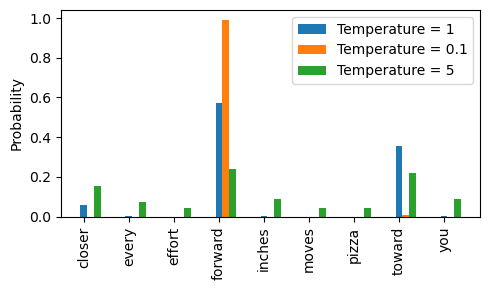

In [58]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

In [59]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [60]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [61]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [62]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [63]:
torch.manual_seed(123)

device = next(model.parameters()).device

token_ids = generate(
    model=model,
    idx=text_token("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print(token_text(token_ids=token_ids,tokenizer=tokenizer))


Every effort moves you. and had" had in it--- he to to. the,


In [64]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [65]:
import tensorflow as tf
import tqdm as tqdm


In [66]:
%ls


 Volume in drive C is OS
 Volume Serial Number is 2646-9520

 Directory of c:\Users\kanha\OneDrive\Documents\Cv

10-03-2026  16:07    <DIR>          .
10-03-2026  00:38    <DIR>          ..
10-03-2026  02:01    <DIR>          __pycache__
08-02-2026  22:17            16,213 demo.mp4
18-01-2026  01:12           101,167 emma.jpg
07-02-2026  16:17             4,100 gpt_download3.py
11-03-2026  21:19           173,045 GPT_with_prediction (1).ipynb
07-02-2026  16:18    <DIR>          gpt2
18-01-2026  01:12             5,402 hrithil.jpeg
07-03-2026  22:28            44,809 model.ipynb
09-02-2026  17:35            46,720 opencv.ipynb
03-03-2026  19:44             2,029 p.py
18-01-2026  01:12             5,291 shruti.jpeg
11-03-2026  21:08            31,550 SMS Spam LLm.ipynb
10-03-2026  15:48    <DIR>          sms_spam_collection
10-03-2026  15:48           203,415 sms_spam_collection.zip
08-02-2026  23:52             1,066 tempCodeRunnerFile.ipynb
11-03-2026  21:19            14,010 temperatu

In [67]:
from gpt_download3 import download_and_load_gpt2


Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
%%writefile gpt_download3.py
import os
import requests
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer


def download_and_load_gpt2(model_name="gpt2", device=None):
    """
    Downloads and loads GPT-2 using Hugging Face.
    This replaces older custom GPT-2 download scripts.
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Loading GPT-2 model: {model_name}")
    print(f"Using device: {device}")

    tokenizer = GPT2Tokenizer.from_pretrained(model_name)
    model = GPT2LMHeadModel.from_pretrained(model_name)
    model.to(device)
    model.eval()

    return model, tokenizer


In [68]:
from gpt_download3 import download_and_load_gpt2



In [69]:
import os
import requests  # Make sure requests is installed
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm

def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path)

    ## We have reached here until now ---> we have downloaded the files on our local machine.

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json")))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params

def download_file(url, destination):
    try:
        # Send a GET request to download the file, disabling SSL verification
        response = requests.get(url, stream=True, verify=False)

        # Get the total file size from headers, defaulting to 0 if not present
        file_size = int(response.headers.get("content-length", 0))

        # Check if file exists and has the same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return

        # Define the block size for reading the file
        block_size = 1024  # 1 Kilobyte

        # Initialize the progress bar with total file size
        progress_bar_description = url.split("/")[-1]  # Extract filename from URL
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
            # Open the destination file in binary write mode
            with open(destination, "wb") as file:
                # Iterate over the file data in chunks
                for chunk in response.iter_content(block_size):
                    progress_bar.update(len(chunk))  # Update progress bar
                    file.write(chunk)  # Write the chunk to the file

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        print(f"Please check the URL: {url}")

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [70]:
import os
import requests  # Make sure requests is installed
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm

def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path)

    ## We have reached here until now ---> we have downloaded the files on our local machine.

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json")))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params

def download_file(url, destination):
    try:
        # Send a GET request to download the file, disabling SSL verification
        response = requests.get(url, stream=True, verify=False)

        # Get the total file size from headers, defaulting to 0 if not present
        file_size = int(response.headers.get("content-length", 0))

        # Check if file exists and has the same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return

        # Define the block size for reading the file
        block_size = 1024  # 1 Kilobyte

        # Initialize the progress bar with total file size
        progress_bar_description = url.split("/")[-1]  # Extract filename from URL
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
            # Open the destination file in binary write mode
            with open(destination, "wb") as file:
                # Iterate over the file data in chunks
                for chunk in response.iter_content(block_size):
                    progress_bar.update(len(chunk))  # Update progress bar
                    file.write(chunk)  # Write the chunk to the file

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        print(f"Please check the URL: {url}")

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [74]:
from gpt_download3 import download_and_load_gpt2


In [75]:

settings,params=download_and_load_gpt2(model_size="124M",models_dir="gpt2")

c:\Users\kanha\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\checkpoint


c:\Users\kanha\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\encoder.json


c:\Users\kanha\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

File already exists and is up-to-date: gpt2\124M\model.ckpt.index


c:\Users\kanha\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\model.ckpt.meta


c:\Users\kanha\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [76]:

print(params.keys())
print("wte shape:", params["wte"].shape)
print("wpe shape:", params["wpe"].shape)
print("ln_f keys:", params["ln_f"].keys())



dict_keys(['blocks', 'ln_f', 'wpe', 'wte'])
wte shape: (50257, 768)
wpe shape: (1024, 768)
ln_f keys: dict_keys(['b', 'g'])


In [77]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

In [78]:
ckpt_path = tf.train.latest_checkpoint("gpt2/124M")

all_vars = tf.train.list_variables(ckpt_path)

for name, _ in all_vars[:20]:
    print(name)

model/h0/attn/c_attn/b
model/h0/attn/c_attn/w
model/h0/attn/c_proj/b
model/h0/attn/c_proj/w
model/h0/ln_1/b
model/h0/ln_1/g
model/h0/ln_2/b
model/h0/ln_2/g
model/h0/mlp/c_fc/b
model/h0/mlp/c_fc/w
model/h0/mlp/c_proj/b
model/h0/mlp/c_proj/w
model/h1/attn/c_attn/b
model/h1/attn/c_attn/w
model/h1/attn/c_proj/b
model/h1/attn/c_proj/w
model/h1/ln_1/b
model/h1/ln_1/g
model/h1/ln_2/b
model/h1/ln_2/g


In [79]:
for name, _ in all_vars:
    if "wte" in name or "wpe" in name or "ln_f" in name:
        print(name)


model/ln_f/b
model/ln_f/g
model/wpe
model/wte


In [80]:
print(settings)

{'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [81]:
print(params.keys())

dict_keys(['blocks', 'ln_f', 'wpe', 'wte'])


In [82]:
print(params['wte'])

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]


In [83]:
model_config={
    "gpt2-small {124M}":{"emb_dim":768,"n_layers":12,"n_heads":12},
    "gpt2-medium {355M}":{"emb_dim":1024,"n_layers":24,'n_heads':16},
    "gpt2-large {774M}":{"emb_dim":1280,"n_layers":36,"n_heads":20},
    "gpt2-xl {1558M}":{"emb_dim":1600,"n_layers":48,"n_heads":25}

}
model_name="gpt2-small {124M}"
New_config=GPT_CONFIG_124M.copy()
New_config.update(model_config[model_name])

In [84]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [85]:
New_config.update({"context_length":1024,"qkv_bias":True})
gpt=GPTModel(New_config)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [86]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["ln_f"]["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["ln_f"]["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])



In [87]:
print(params["ln_f"]["g"])

[1.3970804e+00 1.3749529e+00 1.8869568e+00 1.1688368e+00 1.2723849e+00
 1.2508119e+00 9.4198198e+00 1.4370559e+00 1.4527462e+00 1.1855773e+00
 1.3945330e+00 1.2796482e+00 1.2070800e+00 1.2951057e+00 1.2775753e+00
 1.3480164e+00 1.5088185e+00 1.3728774e+00 1.3426927e+00 2.3760843e+00
 1.1377202e+00 1.2908599e+00 1.3477147e+00 1.4774984e+00 1.2540178e+00
 1.1998552e+00 1.4932117e+00 1.1637024e+00 1.2589843e+00 1.2304723e+00
 1.1833128e+00 1.1914355e+00 1.2228330e+00 1.2792162e+00 1.3293614e+00
 1.6213129e+00 1.3804217e+01 1.1870916e+00 1.2235218e+00 1.4578456e+00
 1.1686537e+00 1.3164082e+00 1.1444045e+00 1.2628103e+00 1.4781330e+00
 1.2425883e+00 1.1744479e+00 1.1601930e+00 1.3636894e+00 2.1280134e+00
 1.2370743e+00 1.2336438e+00 1.7409977e+00 1.1567860e+00 1.3302860e+00
 1.8593032e+00 1.2931563e+00 1.3320310e+00 1.2148480e+00 1.5414531e+00
 1.3780581e+00 1.2070333e+00 1.4030386e+00 1.5723916e+00 7.6158573e-03
 1.1835942e+00 1.2148445e+00 1.2604263e+00 1.8500011e+00 1.1540035e+00
 1.293

In [88]:
load_weights_into_gpt(gpt,params)


In [ ]:
torch.manual_seed(123)
token_ids=generate(
    model=gpt,
    idx=text_token("Every effort moves you",tokenizer),
    max_new_tokens=25,
    context_size=New_config["context_length"],
    top_k=50,
    temperature=1.2
)
print("Output:",token_text(token_ids,tokenizer))

Output: Every effort moves you toward finding an ideal new way to practice something!

What makes this site unique is that it enables me to provide my


In [91]:
import urllib.request
import ssl
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    ssl_context = ssl._create_unverified_context()

    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [92]:
import pandas as pd
df=pd.read_csv(data_file_path,sep="\t",header=None,names=["Label","Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [93]:
def create_balanced_datasset(df):
    num_spam=df[df["Label"]=="spam"].shape[0]
    ham_subset=df[df["Label"]=="ham"].sample(num_spam,random_state=123)
    balanced_df=pd.concat([ham_subset,df[df["Label"]=="spam"]])
    return balanced_df
balanced_df=create_balanced_datasset(df)
balanced_df["Label"].value_counts()

Label
ham     747
spam    747
Name: count, dtype: int64

In [94]:
balanced_df["Label"]=balanced_df["Label"].map({"ham":0,"spam":1})

In [95]:
def random_split(df,train_part,val_part):
    df=df.sample(frac=1,random_state=123).reset_index(drop=True)
    train_end=int(len(df)*train_part)
    train_df=df[:train_end]
    val_end=train_end+int(len(df)*val_part)
    val_df=df[train_end:val_end]
    test_df=df[val_end:]
    return train_df,val_df,test_df
train_df,val_df,test_df=random_split(balanced_df,0.7,0.1)


In [96]:
train_df.to_csv("train.csv",index=None)
val_df.to_csv("val.csv",index=None)
test_df.to_csv("test.csv",index=None)

In [97]:
import tiktoken

In [98]:
import torch
from torch.utils.data import DataLoader,Dataset
class SpamDataset(Dataset):
    def __init__(self,csv_file,tokenizer,max_length=None,pad_token_id=50256):
        self.data=pd.read_csv(csv_file)
        self.encoded_texts=[tokenizer.encode(text) for text in self.data["Text"]]
        if max_length is None:
            self.max_length=self.longest_encoded_length()
        else:
            self.max_length=max_length
            self.encoded_texts=[
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
                           ]
        self.encoded_texts=[
            encoded_text+[pad_token_id]*(self.max_length-len(encoded_text))
            for encoded_text in self.encoded_texts
                            ]
    def __getitem__(self,index):
            encoded=self.encoded_texts[index]
            label=self.data.iloc[index]["Label"]
            return (
                torch.tensor(encoded,dtype=torch.long),
                torch.tensor(label,dtype=torch.long)

            )
    def __len__(self):
            return len(self.data)
        
    def longest_encoded_length(self):
            max_length=0
            for encoded_text in self.encoded_texts:
                encoded_length=len(encoded_text)
                if encoded_length>max_length:
                    max_length=encoded_length
            return max_length



        

In [99]:
tokenizer=tiktoken.get_encoding("gpt2")

In [100]:
train_dataset=SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)
print(train_dataset.max_length)

120


In [101]:
val_dataset=SpamDataset(
    csv_file="val.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset=SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)


In [102]:
torch.manual_seed(123)
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    drop_last=True
)
val_loader=DataLoader(
    dataset=val_dataset,
    batch_size=8,
    num_workers=0,
    drop_last=False
)
test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=8,
    num_workers=0,
    drop_last=False
)

In [103]:
model_config={
    "gpt2-small {124M}":{"emb_dim":768,"n_layers":12,"n_heads":12},
    "gpt2-medium {355M}":{"emb_dim":1024,"n_layers":24,'n_heads':16},
    "gpt2-large {774M}":{"emb_dim":1280,"n_layers":36,"n_heads":20},
    "gpt2-xl {1558M}":{"emb_dim":1600,"n_layers":48,"n_heads":25}

}
CHOOSE_MODEL="gpt2-small {124M}"
INPUT_PROMPT="Every effort moves"
BASIC_CONFIG={
    "vocab_size":50257,
    "context_length":1024,
    "drop_rate":0.0,
    "qkv_bias":True
}
BASIC_CONFIG.update(model_config[CHOOSE_MODEL])
assert train_dataset.max_length <=BASIC_CONFIG["context_length"],(
    f"Dataset length {train_dataset.max_length} exceeds model's context"
    f"length {BASIC_CONFIG['context_length']}.Reinitialize data sets with"
    f"max_length ={BASIC_CONFIG["context_length"]}"
)



In [104]:
model_size=CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
model=GPTModel(BASIC_CONFIG)
load_weights_into_gpt(model,params)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [109]:
torch.manual_seed(123)
token_ids=generate(
    model=gpt,
    idx=text_token("Every effort moves you",tokenizer),
    max_new_tokens=15,
    context_size=BASIC_CONFIG["context_length"],
    top_k=50,
    
)
print("Output:",token_text(token_ids,tokenizer))

Output: Every effort moves you forward.

The first step is to understand the importance of your work


In [111]:
text_2=(
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    "'You are a winner you have been specially"
    " selected to recieve $1000 cash or a $2000 award'"
)
token_ids=generate(
    model=gpt,
    idx=text_token(text_2,tokenizer),
    max_new_tokens=23,
    context_size=BASIC_CONFIG["context_length"],
    top_k=50,
    
)
print("Output:",token_text(token_ids,tokenizer))

Output: Is the following text 'spam'? Answer with 'yes' or 'no':'You are a winner you have been specially selected to recieve $1000 cash or a $2000 award' or 'you have been specially selected to receive $1000 cash or a $2000 award' or 'you have been


In [112]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [113]:
for params in model.parameters():
    params.requires_grad-False



In [114]:
torch.manual_seed(123)
num_classes=2
model.out_head=torch.nn.Linear(in_features=BASIC_CONFIG["emb_dim"],out_features=num_classes)

In [116]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad=True
for param in model.final_norm.parameters():
    param.requires_grad=True

In [118]:
inputs=tokenizer.encode("Do you have time")
inputs=torch.tensor(inputs).unsqueeze(0)
print("Inputs:",inputs)
print("Inputs dimensions:",inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [120]:
with torch.no_grad():
    outputs=model(inputs)
print(outputs)
print(outputs.shape)

tensor([[[-1.5883,  0.9920],
         [-3.7208,  7.4510],
         [-2.2642,  6.6005],
         [-3.5965,  3.9889]]])
torch.Size([1, 4, 2])


In [121]:
probabs=torch.softmax(outputs[:,-1,:],dim=-1)
label=torch.argmax(probabs)
print(label.item())

1


In [123]:
def calc_accuracy_loader(data_loader,model,num_batches=None):
    model.eval()
    correct_predictions,num_examples=0,0
    if num_batches is None:
        num_batches=len(data_loader)
    else:
        num_batches=min(num_batches,len(data_loader))
    for i ,(input_batch,target_batch) in enumerate(data_loader):
        if i <num_batches:
            with torch.no_grad():
                logits=model(input_batch)[:,-1,:]
            predicted_labels=torch.argmax(logits,dim=-1)
            num_examples+=predicted_labels.shape[0]
            correct_predictions+=(predicted_labels==target_batch).sum().item()
        else:
            break
    return correct_predictions/num_examples

In [124]:
torch.manual_seed(123)
train_accuracy=calc_accuracy_loader(train_loader,model,num_batches=10)
val_accuracy=calc_accuracy_loader(val_loader,model,num_batches=10)
test_accuracy=calc_accuracy_loader(test_loader,model,num_batches=10)

In [128]:
print(f"{train_accuracy*100:.2f}")

46.25


In [129]:
print(f"{val_accuracy*100:.2f}")

45.00


In [130]:
print(f"{test_accuracy*100:.2f}")

48.75


In [131]:
def calc_loss_batch(input_batch,target_batch,model):
    logits=model(input_batch)[:,-1,:]
    loss=torch.nn.functional.cross_entropy(logits,target_batch)
    return loss

In [133]:
def calc_loss_loader(data_loader,model,num_batches=None):
    total_loss=0
    if len(data_loader)==0:
        return float('nan')
    elif num_batches is None:
        num_batches=len(data_loader)
    else:
        num_batches=min(num_batches,len(data_loader))
    for i ,(input_batch,target_batch) in enumerate(data_loader):
        if i<num_batches:
            loss=calc_loss_batch(input_batch,target_batch,model)
            total_loss+=loss.item()
        else:
            break
    return total_loss/num_batches

In [134]:
with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,5)
    val_loss=calc_loss_loader(val_loader,model,5)
    test_loss=calc_loss_loader(test_loader,model,5)
print(f"{train_loss:.3f}")
print(f"{val_loss:.3f}")
print(f"{test_loss:.3f}")


2.445
2.575
2.314


## Finetuning time


In [138]:
def train_classifier_simple(model,train_loader,val_loader,optimizer,num_epochs,eval_freq,eval_iter):
    train_losses,val_losses,train_accs,val_accs=[],[],[],[]
    example_seen,global_step=0,-1
    for epoch in range(num_epochs):
        model.train()
        for input_batch,target_batch in tqdm(train_loader):
            optimizer.zero_grad()
            loss=calc_loss_batch(input_batch,target_batch,model)
            loss.backward()
            optimizer.step()
            example_seen+=input_batch.shape[0]
            global_step+=1
            if global_step%eval_freq==0:
                train_loss,val_loss=evaluate_model(
                    model,train_loader,val_loader,eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"{epoch+1},,, {train_loss:.3f},,,{val_loss:.3f}")
    train_accuracy=calc_accuracy_loader(train_loader,model,num_batches=eval_iter)
    val_accuracy=calc_accuracy_loader(val_loader,model,num_batches=eval_iter)
    print(f"train accuracy{train_accuracy*100:.2f}",end="")
    print(f"Val accuracy :{val_accuracy*100:.2f}")
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)
    return train_losses,val_losses,train_accs,val_accs,example_seen


In [137]:
def evaluate_model(model,train_loader,val_loader,eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss=calc_loss_loader(train_loader,model,num_batches=eval_iter)
        val_loss=calc_loss_loader(val_loader,model,num_batches=eval_iter)
    model.train()
    return train_loss,val_loss

In [139]:
import time
start=time.time()
torch.manual_seed(123)
optimizer=torch.optim.Adam(model.parameters(),lr=5e-5,weight_decay=0.1)
num_epochs=5
train_losses,val_losses,train_accs,val_accs,examples_seen=train_classifier_simple(
    model,train_loader,val_loader,optimizer,num_epochs=num_epochs,eval_freq=50,eval_iter=5
)
end_time=time.time()
print(f"Time {(start_time-end_time)/60}")

  1%|          | 1/130 [01:18<2:49:16, 78.73s/it]

1,,, 0.769,,,0.708


 39%|███▉      | 51/130 [08:56<18:26, 14.00s/it] 

1,,, 0.661,,,0.588


 78%|███████▊  | 101/130 [16:10<06:54, 14.31s/it]

...

5,,, 0.079,,,0.059


 62%|██████▏   | 81/130 [13:00<12:44, 15.61s/it]

5,,, 0.203,,,0.242


100%|██████████| 130/130 [20:10<00:00,  9.31s/it]


train accuracy97.50Val accuracy :95.00
Time -370.27122562328975


In [140]:
train_accuracy=calc_accuracy_loader(train_loader,model)
val_accuracy=calc_accuracy_loader(val_loader,model)
test_accuracy=calc_accuracy_loader(test_loader,model)
print(train_accuracy*100)
print(val_accuracy*100)
print(test_accuracy*100)

KeyboardInterrupt: 

In [146]:
def classify_review(text,model,tokenizer,max_length=None,pad_token_id=50256):
    model.eval()
    input_ids=tokenizer.encode(text)
    supported_context_length=model.pos_emb.weight.shape[0]
    input_ids=input_ids[:min(max_length,supported_context_length)]
    input_ids+=[pad_token_id]*(max_length-len(input_ids))
    input_tensor=torch.tensor(input_ids).unsqueeze(0)
    with torch.no_grad():
        logits=model(input_tensor)[:,-1,:]
    predicted_label=torch.argmax(logits,dim=-1).item()

    return "spam" if predicted_label==1 else "no spam"

In [148]:
t1="You are a winner you have been specially selected to recieve $1000 M Award as cash"

print(classify_review(
    t1,model,tokenizer,max_length=train_dataset.max_length
))

spam
